# Score Card

In [1]:
# ==========
# 0. 패키지
# ==========
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle, Polygon
from pathlib import Path

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold

In [2]:
# ===============
# 1. 데이터 로드
# ===============
target_col = "fraud"

DATA_DIR = Path('./Data')
train_df = pd.read_csv(DATA_DIR / "train_selection_top30.csv")
test_df = pd.read_csv(DATA_DIR / "test_selection_top30.csv")

X = train_df.drop(columns=[target_col]).copy()
y = train_df[target_col].copy()
X_test = test_df.copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Target mean:", round(y.mean(), 4))

Train shape: (18000, 31)
Test shape : (12000, 30)
Target mean: 0.1582


In [3]:
# =============================================
# 2. CatBoost 최종 모델 학습 후 중요 변수 선택
#    - Modeling_Final.ipynb 기준 파라미터 반영
# =============================================
cat_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "iterations": 300,
    "learning_rate": 0.03,
    "depth": 4,
    "l2_leaf_reg": 5,
    "subsample": 1.0,
    "bootstrap_type": "Bernoulli",
    "random_seed": 2542,
    "auto_class_weights": "Balanced",
    "verbose": -1
}

cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(X, y, verbose=False)

feature_importance = pd.Series(
    cat_model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=False)

print("\n[CatBoost Feature Importance Top 20]")
print(feature_importance.head(20))


[CatBoost Feature Importance Top 20]
accident_parking                21.116702
age_of_driver_sq                11.911096
high_education_ind               9.914592
age_of_driver                    7.833840
witness_present_ind              5.432908
marital_status                   4.809820
address_change_ind               4.544875
zip_rate_x_accident_highway      3.925669
claim_year                       2.675797
age_over_safety                  1.849636
no_verification                  1.839202
safety_risk_score                1.809722
vehicle_price_per_driver_age     1.651003
female_x_zip_fraud_rate_oof      1.623002
liab_prct_sq                     1.526742
age_of_driver_x_safty_rating     1.514632
age_of_driver_x_liab_prct        1.484249
safty_rating_x_liab_prct         1.413756
vehicle_weight_x_liab_prct       1.409028
witness_absent                   1.386559
dtype: float64


In [4]:
# -----------------------------
# scorecard용 변수 개수 조절
# -----------------------------
top_n = 15
selected_features = feature_importance.head(top_n).index.tolist()

print(f"\nSelected top {top_n} features for scorecard:")
print(selected_features)


Selected top 15 features for scorecard:
['accident_parking', 'age_of_driver_sq', 'high_education_ind', 'age_of_driver', 'witness_present_ind', 'marital_status', 'address_change_ind', 'zip_rate_x_accident_highway', 'claim_year', 'age_over_safety', 'no_verification', 'safety_risk_score', 'vehicle_price_per_driver_age', 'female_x_zip_fraud_rate_oof', 'liab_prct_sq']


In [5]:
# ======================================
# 3. WOE binning 함수
#    - monotonic binning 기반
#    - 수치형 변수 전용
#    - 인접 bin merge로 monotonic 보장
# ======================================
def _is_monotonic(arr, direction="auto", tol=1e-12):
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]

    if len(arr) <= 2:
        return True

    diff = np.diff(arr)

    if direction == "increasing":
        return np.all(diff >= -tol)
    elif direction == "decreasing":
        return np.all(diff <= tol)
    else:
        return np.all(diff >= -tol) or np.all(diff <= tol)


def _merge_bin_rows(rows, i):
    # rows[i] 와 rows[i+1]를 merge
    rows[i]["upper"] = rows[i + 1]["upper"]
    rows[i]["total"] += rows[i + 1]["total"]
    rows[i]["bad"] += rows[i + 1]["bad"]
    rows[i]["good"] += rows[i + 1]["good"]
    rows.pop(i + 1)
    return rows


def _build_monotonic_bins_for_numeric(x, y, max_bins=5, min_bin_pct=0.05):
    # 수치형 변수에 대해 초기 qcut 생성 후,
    # bad rate가 monotonic이 되도록 인접 bin을 반복 merge
    temp = pd.DataFrame({"x": x, "y": y}).dropna().copy()

    # 결측이 아닌 데이터가 너무 적으면 단일 bin
    if len(temp) == 0:
        return [-np.inf, np.inf], "increasing"

    # 초기 bin 수 조정
    n_unique = temp["x"].nunique()
    q = min(max_bins, n_unique)

    if q < 2:
        return [-np.inf, np.inf], "increasing"

    try:
        _, init_edges = pd.qcut(temp["x"], q=q, duplicates="drop", retbins=True)
    except Exception:
        return [-np.inf, np.inf], "increasing"

    init_edges = np.unique(init_edges)

    # edge가 2개 미만이면 bin 생성 불가
    if len(init_edges) < 3:
        return [-np.inf, np.inf], "increasing"

    temp["bin"] = pd.cut(temp["x"], bins=init_edges, include_lowest=True, right=True)

    grouped = (
        temp.groupby("bin", observed=False)["y"]
        .agg(["count", "sum"])
        .reset_index()
        .rename(columns={"count": "total", "sum": "bad"})
    )
    grouped["good"] = grouped["total"] - grouped["bad"]
    grouped["lower"] = grouped["bin"].apply(lambda z: z.left)
    grouped["upper"] = grouped["bin"].apply(lambda z: z.right)
    grouped["bad_rate"] = grouped["bad"] / grouped["total"]

    rows = grouped[["lower", "upper", "total", "bad", "good", "bad_rate"]].to_dict("records")

    # 방향 결정: x와 y 상관 기준
    corr = temp[["x", "y"]].corr(method="spearman").iloc[0, 1]
    direction = "increasing" if pd.isna(corr) or corr >= 0 else "decreasing"

    min_count = max(1, int(np.ceil(len(temp) * min_bin_pct)))

    changed = True
    while changed and len(rows) > 2:
        changed = False

        # 1) 너무 작은 bin 먼저 merge
        small_idx = None
        for i, r in enumerate(rows):
            if r["total"] < min_count:
                small_idx = i
                break

        if small_idx is not None:
            if small_idx == 0:
                rows = _merge_bin_rows(rows, 0)
            elif small_idx == len(rows) - 1:
                rows = _merge_bin_rows(rows, len(rows) - 2)
            else:
                left_gap = abs(rows[small_idx]["bad_rate"] - rows[small_idx - 1]["bad_rate"])
                right_gap = abs(rows[small_idx]["bad_rate"] - rows[small_idx + 1]["bad_rate"])
                if left_gap <= right_gap:
                    rows = _merge_bin_rows(rows, small_idx - 1)
                else:
                    rows = _merge_bin_rows(rows, small_idx)
            for r in rows:
                r["bad_rate"] = r["bad"] / r["total"]
            changed = True
            continue

        # 2) monotonic 위반 merge
        bad_rates = [r["bad_rate"] for r in rows]

        violation_idx = None
        if direction == "increasing":
            for i in range(len(bad_rates) - 1):
                if bad_rates[i] > bad_rates[i + 1]:
                    violation_idx = i
                    break
        else:
            for i in range(len(bad_rates) - 1):
                if bad_rates[i] < bad_rates[i + 1]:
                    violation_idx = i
                    break

        if violation_idx is not None:
            rows = _merge_bin_rows(rows, violation_idx)
            for r in rows:
                r["bad_rate"] = r["bad"] / r["total"]
            changed = True

    # 최종 edges 생성
    edges = [rows[0]["lower"]]
    for r in rows:
        edges.append(r["upper"])
    edges = np.unique(edges).tolist()

    # 안전하게 양 끝 확장
    edges[0] = -np.inf
    edges[-1] = np.inf

    return edges, direction


def fit_woe_binning(train_x, train_y, features, n_bins=5, min_bin_size=0.05, eps=1e-6):
    # monotonic binning + WOE
    binning_result = {}

    temp_df = train_x[features].copy()
    temp_df["_target_"] = train_y.values

    total_good = (temp_df["_target_"] == 0).sum()
    total_bad = (temp_df["_target_"] == 1).sum()

    for col in features:
        s = temp_df[col].copy()
        nunique = s.nunique(dropna=True)

        # low-cardinality 변수는 기존처럼 값 기준 처리
        if nunique <= 2:
            grouped = temp_df.groupby(col, dropna=False)["_target_"].agg(["count", "sum"])
            grouped.columns = ["total", "bad"]
            grouped["good"] = grouped["total"] - grouped["bad"]

            grouped["dist_good"] = (grouped["good"] + eps) / (total_good + eps * len(grouped))
            grouped["dist_bad"] = (grouped["bad"] + eps) / (total_bad + eps * len(grouped))
            grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
            grouped["iv_bin"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

            mapping = grouped["woe"].to_dict()

            binning_result[col] = {
                "type": "categorical_numeric",
                "mapping": mapping,
                "table": grouped.reset_index().rename(columns={col: "bin_value"}),
                "iv": grouped["iv_bin"].sum(),
                "direction": "categorical"
            }

        else:
            try:
                bin_edges, direction = _build_monotonic_bins_for_numeric(
                    x=s,
                    y=temp_df["_target_"],
                    max_bins=n_bins,
                    min_bin_pct=min_bin_size
                )

                cut_s = pd.cut(s, bins=bin_edges, include_lowest=True, right=True)

                grouped = temp_df.groupby(cut_s, dropna=False, observed=False)["_target_"].agg(["count", "sum"])
                grouped.columns = ["total", "bad"]
                grouped["good"] = grouped["total"] - grouped["bad"]

                grouped["dist_good"] = (grouped["good"] + eps) / (total_good + eps * len(grouped))
                grouped["dist_bad"] = (grouped["bad"] + eps) / (total_bad + eps * len(grouped))
                grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
                grouped["iv_bin"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

                interval_to_woe = grouped["woe"].to_dict()

                table = grouped.reset_index()
                first_col = table.columns[0]
                table = table.rename(columns={first_col: "bin_interval"})

                binning_result[col] = {
                    "type": "continuous",
                    "bin_edges": bin_edges,
                    "mapping": interval_to_woe,
                    "table": table,
                    "iv": grouped["iv_bin"].sum(),
                    "direction": direction
                }

            except Exception:
                # fallback: unique value 처리
                grouped = temp_df.groupby(col, dropna=False)["_target_"].agg(["count", "sum"])
                grouped.columns = ["total", "bad"]
                grouped["good"] = grouped["total"] - grouped["bad"]

                grouped["dist_good"] = (grouped["good"] + eps) / (total_good + eps * len(grouped))
                grouped["dist_bad"] = (grouped["bad"] + eps) / (total_bad + eps * len(grouped))
                grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
                grouped["iv_bin"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

                mapping = grouped["woe"].to_dict()

                binning_result[col] = {
                    "type": "categorical_numeric",
                    "mapping": mapping,
                    "table": grouped.reset_index().rename(columns={col: "bin_value"}),
                    "iv": grouped["iv_bin"].sum(),
                    "direction": "fallback"
                }

    return binning_result


def apply_woe_binning(df, binning_result, features):
    result = pd.DataFrame(index=df.index)

    for col in features:
        info = binning_result[col]
        s = df[col].copy()

        if info["type"] == "continuous":
            cut_s = pd.cut(
                s,
                bins=info["bin_edges"],
                include_lowest=True,
                right=True
            )
            result[col] = cut_s.map(info["mapping"]).astype(float)
            result[col] = result[col].fillna(0.0)

        else:
            result[col] = s.map(info["mapping"]).astype(float)
            result[col] = result[col].fillna(0.0)

    return result


def plot_binning_summary(binning_result, feature_name):
    # 특정 변수의 bin별 bad rate / WOE 요약 확인용
    info = binning_result[feature_name]
    table = info["table"].copy()

    table["bad_rate"] = table["bad"] / table["total"]

    print(f"\n[Feature] {feature_name}")
    print(f"Type      : {info['type']}")
    print(f"Direction : {info.get('direction', 'N/A')}")
    print(f"IV        : {info['iv']:.6f}")
    print(table[["bin_interval" if 'bin_interval' in table.columns else "bin_value",
                 "total", "bad", "good", "bad_rate", "woe", "iv_bin"]])

In [6]:
# =======================
# 4. IV 확인 + WOE 변환
# =======================
binning_result = fit_woe_binning(
    X,
    y,
    selected_features,
    n_bins=5,
    min_bin_size=0.05
)

iv_df = pd.DataFrame({
    "feature": selected_features,
    "iv": [binning_result[f]["iv"] for f in selected_features],
    "direction": [binning_result[f].get("direction", "N/A") for f in selected_features]
}).sort_values("iv", ascending=False)

print("\n[IV Table]")
print(iv_df)

X_woe = apply_woe_binning(X, binning_result, selected_features)
X_test_woe = apply_woe_binning(X_test, binning_result, selected_features)

print("\nWOE train shape:", X_woe.shape)
print("WOE test shape :", X_test_woe.shape)

# 확인용: 상위 IV 변수 몇 개 binning 결과 보기
for feat in iv_df["feature"].head(5):
    plot_binning_summary(binning_result, feat)


[IV Table]
                         feature        iv    direction
0               accident_parking  0.128987  categorical
1               age_of_driver_sq  0.077420   decreasing
3                  age_of_driver  0.077420   decreasing
2             high_education_ind  0.074743  categorical
5                 marital_status  0.047199  categorical
4            witness_present_ind  0.046818  categorical
10               no_verification  0.046818  categorical
7    zip_rate_x_accident_highway  0.043613   increasing
6             address_change_ind  0.040494  categorical
8                     claim_year  0.018513  categorical
12  vehicle_price_per_driver_age  0.017604   increasing
13   female_x_zip_fraud_rate_oof  0.016144   increasing
11             safety_risk_score  0.015410   increasing
9                age_over_safety  0.005829   decreasing
14                  liab_prct_sq  0.005316   decreasing

WOE train shape: (18000, 15)
WOE test shape : (12000, 15)

[Feature] accident_parking
Type 

In [7]:
# =============================
# 5. Logistic Regression 학습
# =============================
lr_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_woe, y)

train_pred = lr_model.predict_proba(X_woe)[:, 1]

print("\n[Logistic on WOE]")
print("Train ROC-AUC :", round(roc_auc_score(y, train_pred), 6))
print("Train PR-AUC  :", round(average_precision_score(y, train_pred), 6))


[Logistic on WOE]
Train ROC-AUC : 0.697259
Train PR-AUC  : 0.283866


In [8]:
# ===========================================================
# 6. 간단한 CV 성능 확인
#    - surrogate scorecard가 어느 정도 설명력을 가지는지 확인
# ===========================================================
def cv_scorecard_auc(X_raw, y, features, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_pred = np.zeros(len(X_raw))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_raw, y), 1):
        X_tr = X_raw.iloc[tr_idx][features].copy()
        X_va = X_raw.iloc[va_idx][features].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_va = y.iloc[va_idx].copy()

        fold_binning = fit_woe_binning(
            X_tr,
            y_tr,
            features,
            n_bins=5,
            min_bin_size=0.05
        )

        X_tr_woe = apply_woe_binning(X_tr, fold_binning, features)
        X_va_woe = apply_woe_binning(X_va, fold_binning, features)

        fold_model = LogisticRegression(
            penalty="l2",
            C=1.0,
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        )
        fold_model.fit(X_tr_woe, y_tr)
        fold_pred = fold_model.predict_proba(X_va_woe)[:, 1]
        oof_pred[va_idx] = fold_pred

        fold_auc = roc_auc_score(y_va, fold_pred)
        print(f"Fold {fold} AUC: {fold_auc:.6f}")

    cv_auc = roc_auc_score(y, oof_pred)
    cv_pr_auc = average_precision_score(y, oof_pred)
    return cv_auc, cv_pr_auc, oof_pred


cv_auc, cv_pr_auc, oof_pred = cv_scorecard_auc(X, y, selected_features)

print("\n[CV Scorecard Performance]")
print("OOF ROC-AUC :", round(cv_auc, 6))
print("OOF PR-AUC  :", round(cv_pr_auc, 6))

Fold 1 AUC: 0.672053
Fold 2 AUC: 0.701722
Fold 3 AUC: 0.687709
Fold 4 AUC: 0.712093
Fold 5 AUC: 0.693473

[CV Scorecard Performance]
OOF ROC-AUC : 0.693233
OOF PR-AUC  : 0.279518


In [9]:
# ==================
# 7. Score Scaling
# ==================
PDO = 30          # 점수 20점 차이 = odds 2배
BASE_SCORE = 600
BASE_ODDS = 50    # good:bad = 50:1

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print("\n[Scaling Parameters]")
print("factor:", round(factor, 4))
print("offset:", round(offset, 4))


def predict_score(X_woe, model, factor, offset):
    """
    score = offset - factor * log_odds
    fraud=1이 bad라고 가정
    """
    log_odds_bad = model.decision_function(X_woe)   # log(p_bad / p_good)
    score = offset - factor * log_odds_bad
    return score


train_score = predict_score(X_woe, lr_model, factor, offset)
test_score = predict_score(X_test_woe, lr_model, factor, offset)

train_result = train_df.copy()
train_result["score"] = train_score
train_result["pred_proba_bad"] = train_pred

test_result = test_df.copy()
test_result["score"] = test_score
test_result["pred_proba_bad"] = lr_model.predict_proba(X_test_woe)[:, 1]

print("\nTrain score summary")
print(train_result["score"].describe())

print("\nTest score summary")
print(test_result["score"].describe())


[Scaling Parameters]
factor: 43.2809
offset: 430.6843

Train score summary
count    18000.000000
mean       510.936634
std         32.824453
min        405.132585
25%        488.059521
50%        510.089879
75%        533.165805
max        631.734599
Name: score, dtype: float64

Test score summary
count    12000.000000
mean       510.101896
std         32.554463
min        416.472458
25%        487.151140
50%        509.360632
75%        532.126052
max        615.971737
Name: score, dtype: float64


In [10]:
# =========================
# 8. Scorecard Table 생성
#    - 변수별 bin 점수표
# =========================
def build_scorecard_table(binning_result, lr_model, features, factor):
    intercept = lr_model.intercept_[0]
    coefs = pd.Series(lr_model.coef_[0], index=features)

    scorecard_rows = []

    for feat in features:
        coef = coefs[feat]
        info = binning_result[feat]
        table = info["table"].copy()

        if info["type"] == "continuous":
            interval_col = table.columns[0]  # bin_interval
            for _, row in table.iterrows():
                bin_label = row[interval_col]
                woe = row["woe"]
                points = -factor * coef * woe

                scorecard_rows.append({
                    "feature": feat,
                    "bin": str(bin_label),
                    "woe": woe,
                    "coef": coef,
                    "partial_score": points,
                    "iv_bin": row["iv_bin"]
                })

        else:
            value_col = table.columns[0]  # bin_value
            for _, row in table.iterrows():
                bin_label = row[value_col]
                woe = row["woe"]
                points = -factor * coef * woe

                scorecard_rows.append({
                    "feature": feat,
                    "bin": str(bin_label),
                    "woe": woe,
                    "coef": coef,
                    "partial_score": points,
                    "iv_bin": row["iv_bin"]
                })

    scorecard_df = pd.DataFrame(scorecard_rows)

    # intercept는 별도 base points로 분리
    base_points = offset - factor * intercept

    return scorecard_df, base_points, coefs


scorecard_df, base_points, lr_coefs = build_scorecard_table(
    binning_result=binning_result,
    lr_model=lr_model,
    features=selected_features,
    factor=factor
)

print("\nBase Points:", round(base_points, 2))
print("\n[Scorecard Table Sample]")
print(scorecard_df.head(20))


Base Points: 502.93

[Scorecard Table Sample]
                        feature               bin       woe      coef  \
0              accident_parking               0.0 -0.204689 -1.041177   
1              accident_parking               1.0  0.636970 -1.041177   
2              age_of_driver_sq    (-inf, 2116.0] -0.163535 -0.524804   
3              age_of_driver_sq  (2116.0, 2809.0]  0.060450 -0.524804   
4              age_of_driver_sq     (2809.0, inf]  0.619967 -0.524804   
5            high_education_ind               0.0 -0.382915 -1.053520   
6            high_education_ind               1.0  0.196417 -1.053520   
7                 age_of_driver      (-inf, 46.0] -0.163535 -0.524804   
8                 age_of_driver      (46.0, 53.0]  0.060450 -0.524804   
9                 age_of_driver       (53.0, inf]  0.619967 -0.524804   
10          witness_present_ind               0.0 -0.109540 -0.638048   
11          witness_present_ind               1.0  0.429075 -0.638048   
12  

In [11]:
# ================================================
# 9. 고객 점수를 partial score 합산 방식으로 검증
#    - 실제 score와 거의 같아야 정상
# ================================================
def score_from_table(df_raw, binning_result, scorecard_df, features, base_points):
    score_df = pd.DataFrame(index=df_raw.index)
    score_df["base_points"] = base_points

    for feat in features:
        info = binning_result[feat]
        feat_card = scorecard_df[scorecard_df["feature"] == feat].copy()

        if info["type"] == "continuous":
            bin_edges = info["bin_edges"]
            cut_s = pd.cut(df_raw[feat], bins=bin_edges, include_lowest=True).astype(str)
            mapping = dict(zip(feat_card["bin"], feat_card["partial_score"]))
            score_df[feat] = cut_s.map(mapping).fillna(0.0)

        else:
            value_s = df_raw[feat].astype(str)
            mapping = dict(zip(feat_card["bin"], feat_card["partial_score"]))
            score_df[feat] = value_s.map(mapping).fillna(0.0)

    score_df["total_score"] = score_df.sum(axis=1)
    return score_df


train_score_by_table = score_from_table(
    df_raw=X[selected_features],
    binning_result=binning_result,
    scorecard_df=scorecard_df,
    features=selected_features,
    base_points=base_points
)

print("\n[Table-based Score Check]")
print(train_score_by_table["total_score"].head())
print("Difference mean:",
      np.mean(np.abs(train_score_by_table["total_score"].values - train_score)))


[Table-based Score Check]
0    543.393321
1    482.268362
2    499.542857
3    471.577327
4    501.815792
Name: total_score, dtype: float64
Difference mean: 21.333771908200195


In [12]:
# ====================
# 10. score band 생성
# ====================
def make_score_band(score_series):
    return pd.cut(
        score_series,
        bins=[-np.inf, 450, 500, 550, 600, 650, 700, np.inf],
        labels=["<450", "450-500", "500-550", "550-600", "600-650", "650-700", "700+"]
    )

train_result["score_band"] = make_score_band(train_result["score"])
test_result["score_band"] = make_score_band(test_result["score"])

band_summary = train_result.groupby("score_band", observed=False)["fraud"].agg(["count", "mean"])
band_summary.columns = ["n", "bad_rate"]

print("\n[Train Score Band Summary]")
print(band_summary)


[Train Score Band Summary]
               n  bad_rate
score_band                
<450         463  0.410367
450-500     6398  0.242732
500-550     8981  0.117248
550-600     2097  0.024797
600-650       61  0.000000
650-700        0       NaN
700+           0       NaN


In [13]:
# OOF score 생성
oof_score = offset - factor * np.log(oof_pred / (1 - oof_pred))

train_result['oof_score'] = oof_score

# quantile band
train_result['oof_band'] = pd.qcut(
    train_result['oof_score'],
    q=5,
    duplicates='drop'
)

# band별 bad_rate
oof_band_summary = train_result.groupby('oof_band')['fraud'].agg(['count','mean'])
print(oof_band_summary)

                              count      mean
oof_band                                     
(401.89500000000004, 482.35]   3603  0.296142
(482.35, 501.721]              3599  0.199222
(501.721, 518.963]             3598  0.154530
(518.963, 539.052]             3614  0.100166
(539.052, 629.849]             3586  0.040714


## KS Statistic

In [14]:
from scipy.stats import ks_2samp

good = train_result.loc[train_result['fraud']==0, 'oof_score']
bad = train_result.loc[train_result['fraud']==1, 'oof_score']

ks = ks_2samp(good, bad)
print(ks)

KstestResult(statistic=np.float64(0.2759664612080728), pvalue=np.float64(7.506796895974184e-162), statistic_location=np.float64(506.7782410641452), statistic_sign=np.int8(-1))


KS: 0.2760


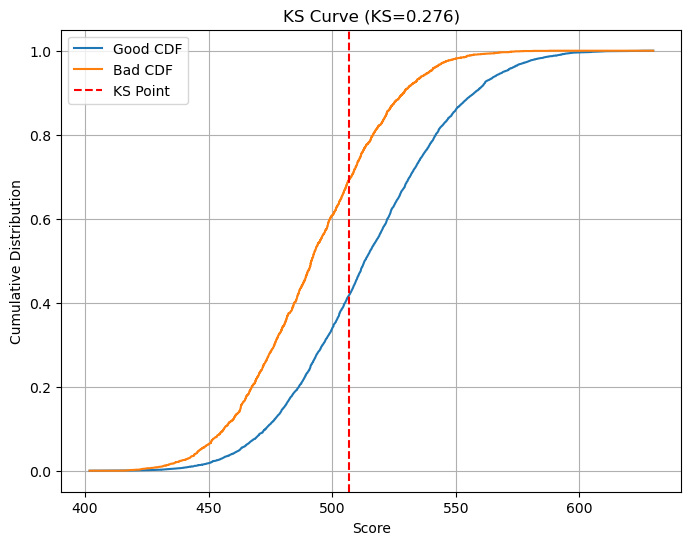

In [15]:
# 데이터 준비
df = train_result.copy()
df = df.sort_values('oof_score')

# good / bad 정의
df['good'] = (df['fraud'] == 0).astype(int)
df['bad'] = (df['fraud'] == 1).astype(int)

# cumulative 비율
df['cum_good'] = df['good'].cumsum() / df['good'].sum()
df['cum_bad'] = df['bad'].cumsum() / df['bad'].sum()

# KS 값
df['ks'] = np.abs(df['cum_good'] - df['cum_bad'])
ks_value = df['ks'].max()
ks_idx = df['ks'].idxmax()

print(f"KS: {ks_value:.4f}")

# Plot
plt.figure(figsize=(8,6))
plt.plot(df['oof_score'], df['cum_good'], label='Good CDF')
plt.plot(df['oof_score'], df['cum_bad'], label='Bad CDF')
plt.axvline(df.loc[ks_idx, 'oof_score'], color='red', linestyle='--', label='KS Point')

plt.title(f'KS Curve (KS={ks_value:.3f})')
plt.xlabel('Score')
plt.ylabel('Cumulative Distribution')
plt.legend()
plt.grid()
plt.show()

- score 500 ~ 505점 기준
- 기준 score 이상 : 안전군
- 기준 score 이하 : 위험군
  
-> 모델이 위험 고객과 정상 고객을 잘 분리중

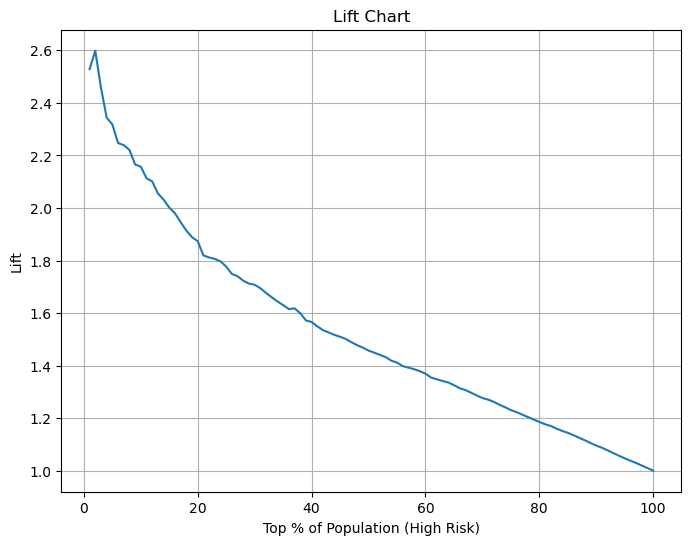

In [16]:
# 내림차순 정렬 (위험 높은 순)
df_lift = train_result.copy()
df_lift = df_lift.sort_values('oof_score')

# 점수 낮을수록 fraud 위험 높음 → ascending=True 유지

df_lift['rank'] = np.arange(1, len(df_lift)+1)
df_lift['cum_bad'] = df_lift['fraud'].cumsum()
df_lift['cum_total'] = df_lift['rank']

# 전체 bad 비율
overall_bad_rate = df_lift['fraud'].mean()

# 누적 bad rate
df_lift['cum_bad_rate'] = df_lift['cum_bad'] / df_lift['cum_total']

# Lift
df_lift['lift'] = df_lift['cum_bad_rate'] / overall_bad_rate

# Top % 기준
percentages = np.linspace(0.01, 1.0, 100)
lift_values = []

for p in percentages:
    cutoff = int(len(df_lift) * p)
    lift_values.append(df_lift.iloc[:cutoff]['lift'].iloc[-1])

# Plot
plt.figure(figsize=(8,6))
plt.plot(percentages*100, lift_values)

plt.title('Lift Chart')
plt.xlabel('Top % of Population (High Risk)')
plt.ylabel('Lift')
plt.grid()
plt.show()

- Top 1% : 평균보다 약 2.6배 더 위험
- Top 10% : 평균 보다 2배 이상 더 위험

In [17]:
# Top-K 요약
for k in [0.01, 0.05, 0.1, 0.2]:
    cutoff = int(len(df_lift) * k)
    sub = df_lift.iloc[:cutoff]
    
    recall = sub['fraud'].sum() / df_lift['fraud'].sum()
    precision = sub['fraud'].mean()
    
    print(f"Top {int(k*100)}%:")
    print(f"  Recall: {recall:.3f}")
    print(f"  Precision: {precision:.3f}")

Top 1%:
  Recall: 0.025
  Precision: 0.400
Top 5%:
  Recall: 0.116
  Precision: 0.367
Top 10%:
  Recall: 0.216
  Precision: 0.341
Top 20%:
  Recall: 0.375
  Precision: 0.296


- 전체 fraud의 21%를 상위 10%에서 잡을 수 있음

## Score Card 시각화

In [18]:
def draw_scorecard_gauge(
    score,
    min_score=400,
    max_score=650,
    bands=None,
    title="FRAUD RISK SCORECARD",
    left_label="HIGH RISK",
    right_label="LOW RISK",
    save_path=None
):
    """
    scorecard 점수를 반원형 게이지로 시각화하는 함수

    Parameters
    ----------
    score : float
        시각화할 점수
    min_score : float
        최소 점수
    max_score : float
        최대 점수
    bands : list of tuples
        [(start, end, color, label), ...]
    title : str
        차트 제목
    left_label : str
        왼쪽 라벨
    right_label : str
        오른쪽 라벨
    save_path : str or None
        저장 경로. 예: 'score_gauge.png'
    """

    if bands is None:
        bands = [
            (400, 450, "#c0392b", "<450"),
            (450, 500, "#e67e22", "450-500"),
            (500, 550, "#f1c40f", "500-550"),
            (550, 600, "#7fbf3f", "550-600"),
            (600, 650, "#2e8b57", "600+"),
        ]

    # 점수 범위 clipping
    score = float(np.clip(score, min_score, max_score))

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_aspect("equal")
    ax.axis("off")

    center = (0, 0)
    radius = 1.0
    width = 0.42

    def score_to_angle(x):
        # 왼쪽 끝 180도, 오른쪽 끝 0도
        return 180 - (x - min_score) / (max_score - min_score) * 180

    # =========================
    # 1. 구간(밴드) 그리기
    # =========================
    for start, end, color, label in bands:
        theta1 = score_to_angle(end)
        theta2 = score_to_angle(start)

        wedge = Wedge(
            center,
            radius,
            theta1,
            theta2,
            width=width,
            facecolor=color,
            edgecolor="white",
            linewidth=2
        )
        ax.add_patch(wedge)

        # 밴드 라벨 위치
        mid_score = (start + end) / 2
        ang = np.deg2rad(score_to_angle(mid_score))
        r_text = radius + 0.18
        x_text = r_text * np.cos(ang)
        y_text = r_text * np.sin(ang)

        ax.text(
            x_text, y_text, label,
            ha="center", va="center",
            fontsize=12, fontweight="bold"
        )

    # ===============
    # 2. 바늘 그리기
    # ===============
    angle = np.deg2rad(score_to_angle(score))
    needle_len = 0.78
    needle_half_width = 0.035

    tip = np.array([needle_len * np.cos(angle), needle_len * np.sin(angle)])
    left = np.array([
        needle_half_width * np.cos(angle + np.pi / 2),
        needle_half_width * np.sin(angle + np.pi / 2)
    ])
    right = np.array([
        needle_half_width * np.cos(angle - np.pi / 2),
        needle_half_width * np.sin(angle - np.pi / 2)
    ])

    needle = Polygon([left, right, tip], closed=True, color="#2c2c2c")
    ax.add_patch(needle)

    # 중심 원
    ax.add_patch(Circle((0, 0), 0.08, color="#2c2c2c"))
    ax.add_patch(Circle((0, 0), 0.035, color="white"))

    # ===========================
    # 3. 제목 / 라벨 / 현재 점수
    # ===========================
    ax.text(
        0, 1.30, title,
        ha="center", va="center",
        fontsize=26, fontweight="bold"
    )

    ax.text(
        -0.82, -0.02, left_label,
        ha="center", va="center",
        fontsize=16, fontweight="bold", color="#c0392b"
    )
    ax.text(
        0.82, -0.02, right_label,
        ha="center", va="center",
        fontsize=16, fontweight="bold", color="#2e8b57"
    )

    ax.text(
        0, -0.24, f"Score: {score:.1f}",
        ha="center", va="center",
        fontsize=20, fontweight="bold"
    )

    # 바깥 여백
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-0.35, 1.45)

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

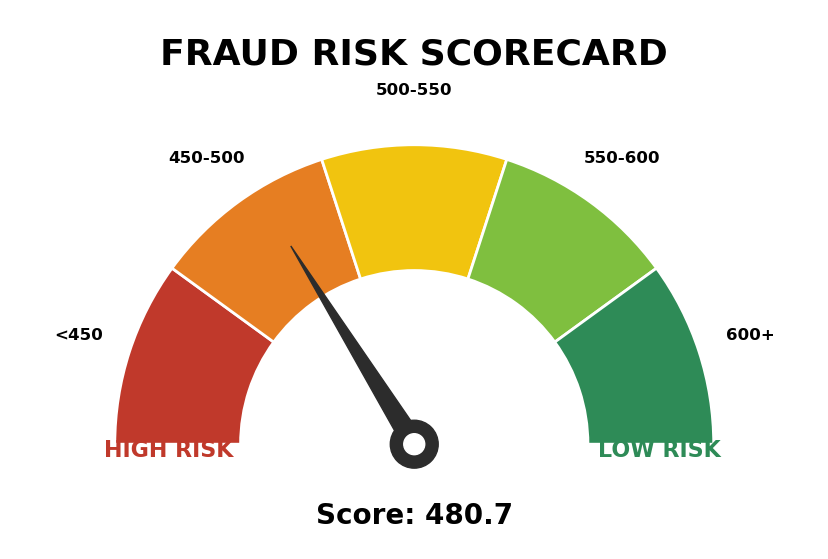

In [31]:
# 데이터에서 실제 고객 1명 시각화
sample_score = test_result.loc[0, "score"]
draw_scorecard_gauge(score=sample_score)

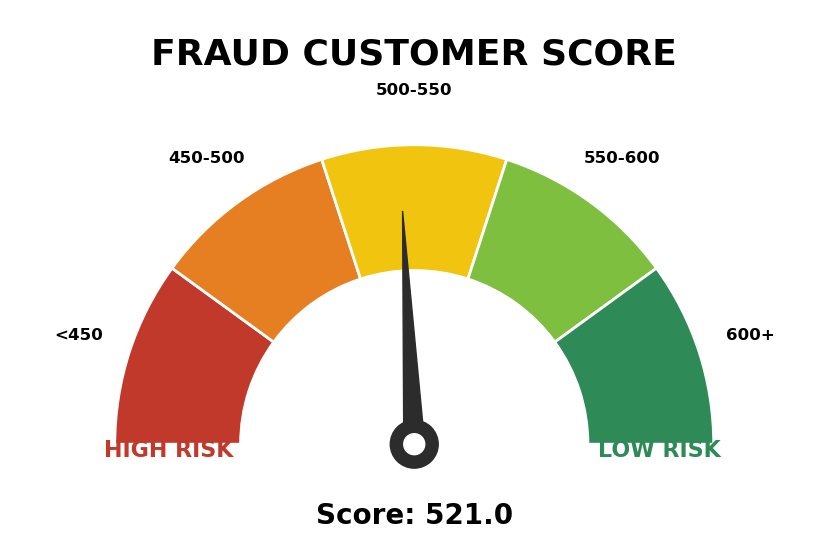

In [35]:
# fraud 고객 시각화
fraud_score = train_result.loc[train_result["fraud"] == 1, "score"].iloc[0]
draw_scorecard_gauge(
    score=fraud_score,
    title="FRAUD CUSTOMER SCORE"
)

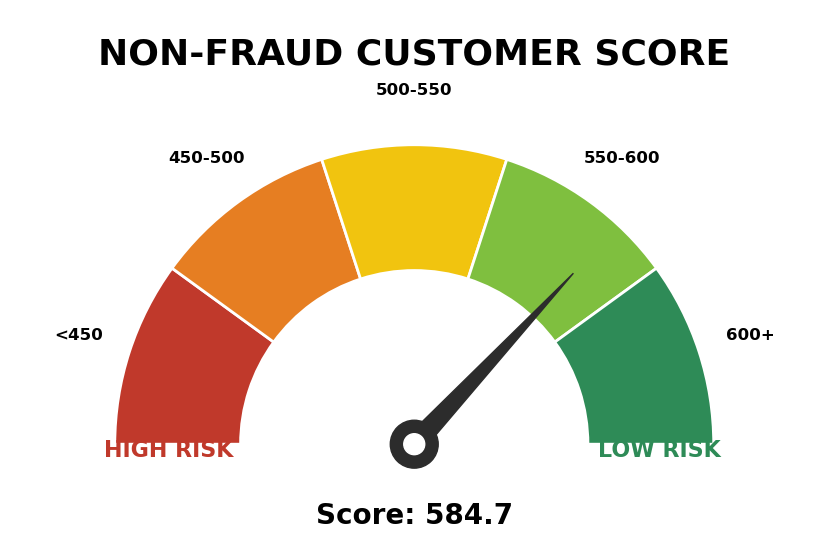

In [34]:
# non-fraud 고객 시각화
good_score = train_result.loc[train_result["fraud"] == 0, "score"].iloc[0]
draw_scorecard_gauge(
    score=good_score,
    title="NON-FRAUD CUSTOMER SCORE"
)

## 시각화 준비

In [22]:
# -------------------------------------------------
# 1) train score 계산
# -------------------------------------------------
def predict_score(X_woe, model, factor, offset):
    """
    fraud=1이 bad라고 가정
    score가 높을수록 더 안전
    """
    log_odds_bad = model.decision_function(X_woe)   # log(p_bad / p_good)
    score = offset - factor * log_odds_bad
    return score

train_score = predict_score(X_woe, lr_model, factor, offset)
train_pred_proba_bad = lr_model.predict_proba(X_woe)[:, 1]

# -------------------------------------------------
# 2) score band 생성
# -------------------------------------------------
def make_score_band(score_series):
    return pd.cut(
        score_series,
        bins=[-np.inf, 450, 500, 550, 600, 650, np.inf],
        labels=["<450", "450-500", "500-550", "550-600", "600-650", "650+"]
    )

train_result = train_df.copy()
train_result["score"] = train_score
train_result["pred_proba_bad"] = train_pred_proba_bad
train_result["score_band"] = make_score_band(train_result["score"])

# -------------------------------------------------
# 3) claim_id 생성
#    - claim_number 컬럼이 있으면 그걸 사용
#    - 없으면 index 기반으로 생성
# -------------------------------------------------
if "claim_number" in train_result.columns:
    train_result["claim_id"] = train_result["claim_number"]
elif "Claim_Number" in train_result.columns:
    train_result["claim_id"] = train_result["Claim_Number"]
elif "claim_id" in train_result.columns:
    train_result["claim_id"] = train_result["claim_id"]
elif "id" in train_result.columns:
    train_result["claim_id"] = train_result["id"]
else:
    train_result = train_result.reset_index(drop=True)
    train_result["claim_id"] = train_result.index.astype(str)

# Tableau용으로 필요한 컬럼만 우선 저장
scorecard_export_cols = ["claim_id", "score", "pred_proba_bad", "score_band"]

# fraud 컬럼 있으면 같이 저장
if "fraud" in train_result.columns:
    scorecard_export_cols.append("fraud")

train_scorecard_result = train_result[scorecard_export_cols].copy()

# 저장
train_scorecard_result.to_csv(DATA_DIR / "train_scorecard_result.csv", index=False)

print(train_scorecard_result.head())

  claim_id       score  pred_proba_bad score_band  fraud
0        0  584.656245        0.027720    550-600    0.0
1        1  531.711004        0.088329    500-550    0.0
2        2  528.484020        0.094520    500-550    0.0
3        3  521.019970        0.110347    500-550    1.0
4        4  520.093331        0.112467    500-550    0.0


In [23]:
# -------------------------------------------------
# 1) scorecard table 기반으로 고객별 partial score 계산
# -------------------------------------------------
def score_from_table(df_raw, binning_result, scorecard_df, features, base_points):
    score_df = pd.DataFrame(index=df_raw.index)
    score_df["base_points"] = base_points

    for feat in features:
        info = binning_result[feat]
        feat_card = scorecard_df[scorecard_df["feature"] == feat].copy()

        if info["type"] == "continuous":
            bin_edges = info["bin_edges"]
            cut_s = pd.cut(df_raw[feat], bins=bin_edges, include_lowest=True).astype(str)
            mapping = dict(zip(feat_card["bin"], feat_card["partial_score"]))
            score_df[feat] = cut_s.map(mapping).fillna(0.0)

        else:
            value_s = df_raw[feat].astype(str)
            mapping = dict(zip(feat_card["bin"], feat_card["partial_score"]))
            score_df[feat] = value_s.map(mapping).fillna(0.0)

    score_df["total_score"] = score_df.sum(axis=1)
    return score_df

# -------------------------------------------------
# 2) base_points 계산
# -------------------------------------------------
intercept = lr_model.intercept_[0]
base_points = offset - factor * intercept

# -------------------------------------------------
# 3) partial score breakdown 계산
# -------------------------------------------------
train_partial_score_breakdown = score_from_table(
    df_raw=X[selected_features],
    binning_result=binning_result,
    scorecard_df=scorecard_df,
    features=selected_features,
    base_points=base_points
).copy()

# -------------------------------------------------
# 4) claim_id 붙이기
# -------------------------------------------------
if "claim_number" in train_result.columns:
    train_partial_score_breakdown["claim_id"] = train_result["claim_number"].values
elif "Claim_Number" in train_result.columns:
    train_partial_score_breakdown["claim_id"] = train_result["Claim_Number"].values
elif "claim_id" in train_result.columns:
    train_partial_score_breakdown["claim_id"] = train_result["claim_id"].values
elif "id" in train_result.columns:
    train_partial_score_breakdown["claim_id"] = train_result["id"].values
else:
    train_partial_score_breakdown["claim_id"] = train_result["claim_id"].values

# 컬럼 순서 정리
cols = ["claim_id"] + [c for c in train_partial_score_breakdown.columns if c != "claim_id"]
train_partial_score_breakdown = train_partial_score_breakdown[cols]

# 저장
train_partial_score_breakdown.to_csv(DATA_DIR / "train_partial_score_breakdown.csv", index=False)

print(train_partial_score_breakdown.head())

  claim_id  base_points  accident_parking  age_of_driver_sq  \
0        0   502.925444               0.0         14.081898   
1        1   502.925444               0.0         -3.714515   
2        2   502.925444               0.0         -3.714515   
3        3   502.925444               0.0         -3.714515   
4        4   502.925444               0.0         -3.714515   

   high_education_ind  age_of_driver  witness_present_ind  marital_status  \
0                 0.0      14.081898                  0.0        6.298905   
1                 0.0      -3.714515                  0.0      -13.248526   
2                 0.0      -3.714515                  0.0      -13.248526   
3                 0.0      -3.714515                  0.0      -13.248526   
4                 0.0      -3.714515                  0.0        6.298905   

   address_change_ind  zip_rate_x_accident_highway  claim_year  \
0                 0.0                     2.749353         0.0   
1                 0.0     

In [24]:
# -------------------------------------------------
# Tableau waterfall용 long format 생성
# -------------------------------------------------
partial_long = train_partial_score_breakdown.melt(
    id_vars=["claim_id"],
    var_name="feature",
    value_name="contribution"
)

# waterfall에서는 total/base도 상황에 따라 따로 다루는 게 좋음
# 우선 total_score는 제외
partial_long = partial_long[partial_long["feature"] != "total_score"].copy()

partial_long.to_csv(DATA_DIR / "train_partial_score_breakdown_long.csv", index=False)

print(partial_long.head())

  claim_id      feature  contribution
0        0  base_points    502.925444
1        1  base_points    502.925444
2        2  base_points    502.925444
3        3  base_points    502.925444
4        4  base_points    502.925444


In [26]:
partial_long.nunique()

claim_id        18000
feature            16
contribution       22
dtype: int64

In [28]:
print(partial_long["claim_id"].head(10))
print(partial_long["claim_id"].min())
print(partial_long["claim_id"].max())
print(partial_long["claim_id"].dtype)

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: claim_id, dtype: object
0
9999
object


In [27]:
sample = partial_long[partial_long["claim_id"] == 0]
print(sample.sort_values("contribution"))

Empty DataFrame
Columns: [claim_id, feature, contribution]
Index: []


In [29]:
sample_claim = partial_long["claim_id"].iloc[0]
print("sample_claim:", sample_claim)

sample = partial_long[partial_long["claim_id"] == sample_claim]
print(sample.sort_values("contribution"))

sample_claim: 0
       claim_id                       feature  contribution
180000        0               age_over_safety     -1.896399
270000        0                  liab_prct_sq     -1.529945
234000        0  vehicle_price_per_driver_age     -0.143722
18000         0              accident_parking      0.000000
54000         0            high_education_ind      0.000000
90000         0           witness_present_ind      0.000000
126000        0            address_change_ind      0.000000
162000        0                    claim_year      0.000000
198000        0               no_verification      0.000000
216000        0             safety_risk_score      2.159654
144000        0   zip_rate_x_accident_highway      2.749353
252000        0   female_x_zip_fraud_rate_oof      4.666235
108000        0                marital_status      6.298905
36000         0              age_of_driver_sq     14.081898
72000         0                 age_of_driver     14.081898
0             0         